# MODEL BASELINE

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import os

# Thiết lập đường dẫn
current_dir = os.getcwd()
base_dir = os.path.dirname(current_dir)
train_path = os.path.join(base_dir, 'data', 'preprocessed', 'train_data.csv')
test_path = os.path.join(base_dir, 'data', 'preprocessed', 'test_data.csv')

# Load dữ liệu đã chia sẵn
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(f"Đã load tập Train: {train_df.shape}")
print(f"Đã load tập Test: {test_df.shape}")

Đã load tập Train: (7292, 14)
Đã load tập Test: (1824, 14)


## 1. Định nghĩa Mô hình Baseline (Mô hình tham chiếu)

Nhóm thống nhất chọn mô hình **Hồi quy tuyến tính đơn biến** làm Baseline với các đặc điểm sau:
* **Biến dự báo (X):** `dien_tich_dat` (Dữ liệu gốc, chưa lấy Log).
* **Biến mục tiêu (y):** `gia` (Đơn vị: Tỷ VNĐ).

**Mục tiêu:** Thiết lập một mốc hiệu suất cho mô hình đơn giản nhất dựa trên yếu tố bản năng nhất của bất động sản (Diện tích). Các mô hình cải tiến của thành viên phía sau phải vượt qua được kết quả của mô hình này.

In [2]:
# 1. Tách X, y từ tập Train và Test
# Lưu ý: X cần ở dạng DataFrame (2D array) nên dùng [['column_name']]
X_train = train_df[['dien_tich_dat']]
y_train = train_df['gia']

X_test = test_df[['dien_tich_dat']]
y_test = test_df['gia']

# 2. Khởi tạo và Huấn luyện mô hình Linear Regression (OLS)
model_baseline = LinearRegression()
model_baseline.fit(X_train, y_train)

print("Huấn luyện mô hình Baseline thành công!")
print(f"Hệ số chặn (Intercept): {model_baseline.intercept_:.4f}")
print(f"Hệ số góc (Coefficient): {model_baseline.coef_[0]:.4f}")

Huấn luyện mô hình Baseline thành công!
Hệ số chặn (Intercept): -0.1710
Hệ số góc (Coefficient): 0.1843


## 2. Dự đoán và đánh giá hiệu suất

In [3]:
# 1. Dự báo trên tập Test
y_pred = model_baseline.predict(X_test)

# 2. Tính toán các chỉ số đánh giá
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# 3. Hiển thị kết quả (Dùng cho bảng so sánh trong báo cáo)
results = pd.DataFrame({
    'Metric': ['R-squared (R2)', 'MAE (Tỷ VNĐ)', 'MSE', 'RMSE (Tỷ VNĐ)'],
    'Value': [r2, mae, mse, rmse]
})

print("--- KẾT QUẢ MÔ HÌNH BASELINE ---")
display(results)

--- KẾT QUẢ MÔ HÌNH BASELINE ---


,Metric,Value
0,R-squared (R2),0.318807
1,MAE (Tỷ VNĐ),5.101425
2,MSE,67.331073
3,RMSE (Tỷ VNĐ),8.205551


## 3. Trực quan hóa đường hồi quy

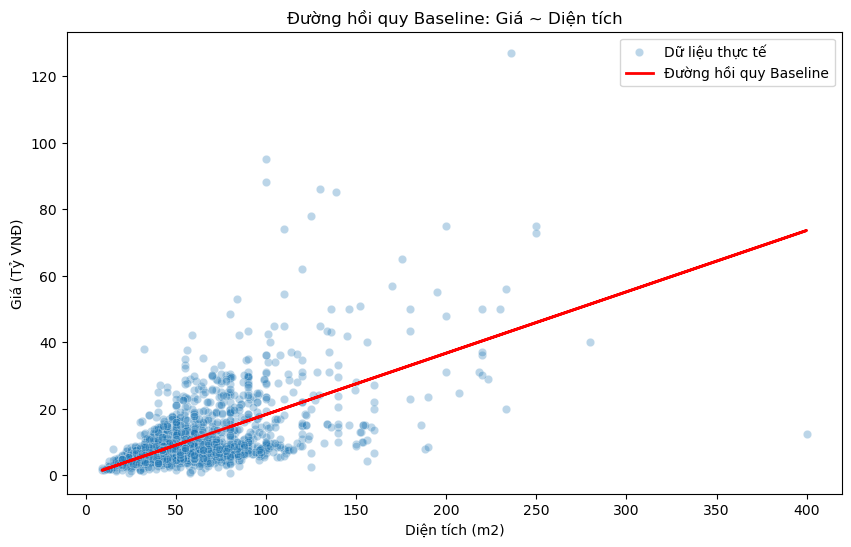

In [4]:
plt.figure(figsize=(10, 6))

# Vẽ điểm dữ liệu thực tế (chỉ vẽ một phần để tránh rối mắt)
sns.scatterplot(x=X_test['dien_tich_dat'], y=y_test, alpha=0.3, label='Dữ liệu thực tế')

# Vẽ đường hồi quy của Baseline
plt.plot(X_test['dien_tich_dat'], y_pred, color='red', linewidth=2, label='Đường hồi quy Baseline')

plt.title("Đường hồi quy Baseline: Giá ~ Diện tích")
plt.xlabel("Diện tích (m2)")
plt.ylabel("Giá (Tỷ VNĐ)")
plt.legend()
plt.show()

## 4. Đánh giá hiệu suất mô hình Baseline

Dựa trên kết quả thực thi và trực quan hóa đường hồi quy, nhóm rút ra các nhận xét quan trọng sau:

* **Độ khớp của mô hình (R-squared ≈ 0.319):** Mô hình chỉ giải thích được khoảng **31.9%** sự biến động của giá nhà dựa trên diện tích đơn thuần. Đây là mức hiệu suất thấp, khẳng định rằng diện tích không phải là yếu tố duy nhất quyết định giá trị bất động sản.
* **Sai số thực tế (MAE ≈ 5.1 tỷ, RMSE ≈ 8.2 tỷ):** 
    - Sai số tuyệt đối trung bình (MAE) lên đến **5.1 tỷ VNĐ**, một con số rất lớn so với giá trị trung bình của các căn nhà. 
    - RMSE (8.2 tỷ) cao hơn hẳn MAE cho thấy mô hình tạo ra các sai số dự báo cực lớn ở những căn nhà có giá trị cao, khiến độ tin cậy của mô hình Baseline này rất thấp.
* **Phân tích biểu đồ Scatter Plot:** 
    - Biểu đồ cho thấy hiện tượng **phương sai thay đổi** rõ rệt: Khi diện tích tăng lên, dải điểm dữ liệu càng lan rộng ra như hình cái phễu, khiến đường hồi quy (màu đỏ) không còn khả năng đại diện tốt cho dữ liệu.
    - Có sự lệch pha lớn giữa đường dự báo và các điểm dữ liệu thực tế ở phân khúc cao cấp, minh chứng cho việc dữ liệu gốc bị lệch (skewed) ảnh hưởng tiêu cực đến thuật toán OLS.

**Kết luận:** Mô hình Baseline hoàn thành vai trò thiết lập "mốc tham chiếu thấp nhất". Kết quả này là động lực để nhóm thực hiện các cải tiến như **biến đổi Logarit** và **bổ sung thêm đặc trưng địa lý (Quận, Thành phố)** nhằm tối ưu hóa độ chính xác ở các mô hình tiếp theo.